In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [2]:
file = '/eos/user/b/bbapi/MC_contacts/2024_signal_samples_WH/CMSSW_15_0_15/src/WH_2024_M60.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

# events = ak.materialize(events)

In [3]:
events.Photon.fields

['cutBased',
 'electronVeto',
 'hasConversionTracks',
 'isScEtaEB',
 'isScEtaEE',
 'mvaID_WP80',
 'mvaID_WP90',
 'pixelSeed',
 'seedGain',
 'electronIdx',
 'jetIdx',
 'seediEtaOriX',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'ecalPFClusterIso',
 'energyErr',
 'energyRaw',
 'esEffSigmaRR',
 'esEnergyOverRawE',
 'eta',
 'etaWidth',
 'haloTaggerMVAVal',
 'hcalPFClusterIso',
 'hoe',
 'hoe_PUcorr',
 'hoe_Tower',
 'mvaID',
 'pfChargedIso',
 'pfChargedIsoPFPV',
 'pfChargedIsoWorstVtx',
 'pfPhoIso03',
 'pfRelIso03_all_quadratic',
 'pfRelIso03_chg_quadratic',
 'phi',
 'phiWidth',
 'pt',
 'r9',
 's4',
 'sieie',
 'sieip',
 'sipip',
 'superclusterEta',
 'trkSumPtHollowConeDR03',
 'trkSumPtSolidConeDR04',
 'x_calo',
 'y_calo',
 'z_calo',
 'genPartFlav',
 'genPartIdx',
 'electronIdxG',
 'genPartIdxG',
 'jetIdxG']

In [3]:
events.fields

['orbitNumber',
 'LowPtElectron',
 'L1',
 'GenPart',
 'run',
 'SubGenJetAK8',
 'GenMET',
 'GenDressedLepton',
 'SoftActivityJetNjets2',
 'PV',
 'RawPFMET',
 'L1Reco',
 'PFCand',
 'FiducialMET',
 'GenIsolatedPhoton',
 'PVBS',
 'bunchCrossing',
 'PuppiMET',
 'luminosityBlock',
 'Rho',
 'FatJet',
 'PFMET',
 'TauSpinner',
 'LHEReweightingWeight',
 'GenJet',
 'TrkMET',
 'SoftActivityJet',
 'SoftActivityJetHT',
 'SoftActivityJetNjets5',
 'HTXS',
 'SoftActivityJetHT2',
 'boostedTau',
 'SV',
 'DST',
 'Flag',
 'SoftActivityJetHT10',
 'SubJet',
 'LHEPart',
 'GenJetAK8',
 'DeepMETResolutionTune',
 'Photon',
 'Dataset',
 'HLT',
 'CaloMET',
 'GenVtx',
 'LHEScaleWeight',
 'SoftActivityJetHT5',
 'OtherPV',
 'event',
 'SoftActivityJetNjets10',
 'Tau',
 'LHEPdfWeight',
 'IsoTrack',
 'HLTriggerFinalPath',
 'TrackGenJetAK4',
 'L1simulation',
 'GenVisTau',
 'MC',
 'LHEWeight',
 'PSWeight',
 'genWeight',
 'TrigObj',
 'LHE',
 'FsrPhoton',
 'RawPuppiMET',
 'TauProd',
 'GenProton',
 'Pileup',
 'Jet',
 'Muon',

In [4]:
Photons = events.Photon
Electrons = events.Electron
Jets = events.Jet
Muons = events.Muon

In [34]:
Jets.fields

['chMultiplicity',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'UParTAK4RegPtRawCorr',
 'UParTAK4RegPtRawCorrNeutrino',
 'UParTAK4RegPtRawRes',
 'UParTAK4V1RegPtRawCorr',
 'UParTAK4V1RegPtRawCorrNeutrino',
 'UParTAK4V1RegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetCvNotB',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagUParTAK4B',
 'btagUParTAK4CvB',
 'btagUParTAK4CvL',
 'btagUParTAK4CvNotB',
 'btagUParTAK4Ele',
 'btagUParTAK4Mu',
 'btagUParTAK4QvG',
 'btagUParTAK4SvCB',
 'btagUParTAK4SvUDG',
 'btagUParTAK4TauVJet',
 'btagUParTAK4UDG',
 'btagUParTAK4probb',
 'btagUParTAK4probbb',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsi

Info in <TCanvas::Print>: png file N_ele_dist_WH_M60_2024.png has been created


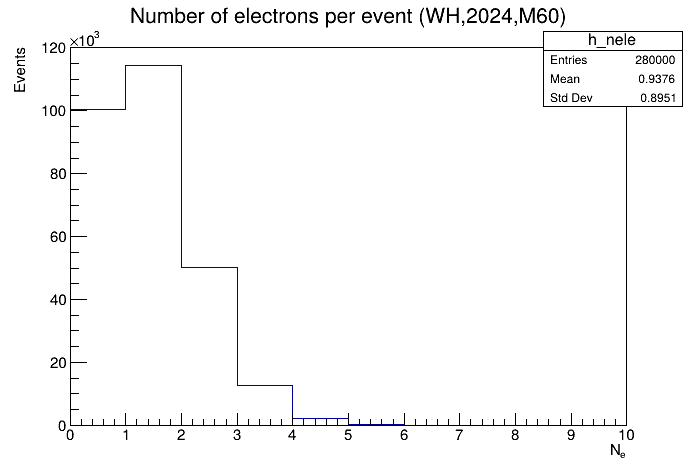

In [5]:
import ROOT
import awkward as ak

# Electrons.pt is an awkward jagged array
nele = ak.num(Electrons.pt)

# Create histogram
h = ROOT.TH1I("h_nele", "Number of electrons per event (WH,2024,M60);N_{e};Events", 10, 0, 10)

# Fill histogram
for n in nele:
    h.Fill(int(n))

# Draw
c = ROOT.TCanvas()
h.Draw("hist")
c.Update()
c.SaveAs("N_ele_dist_WH_M60_2024.png")

Info in <TCanvas::Print>: png file Electron_pT_WH_M60_2024.png has been created


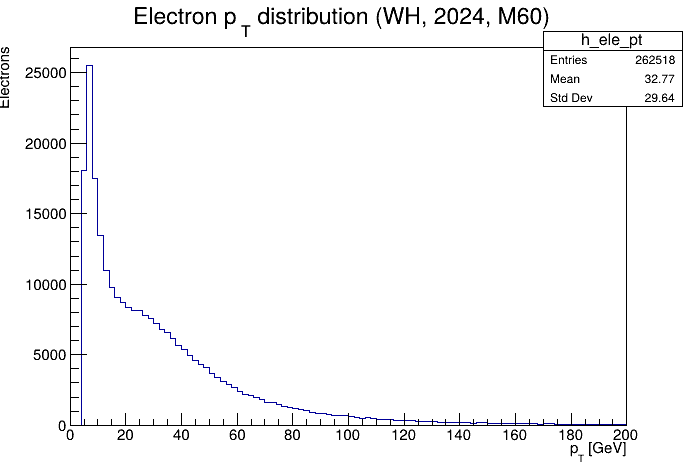

In [6]:
# Electrons.pt is a jagged awkward array: [event][electron]
ele_pt = Electrons.pt

# Create histogram
h = ROOT.TH1F(
    "h_ele_pt",
    "Electron p_{T} distribution (WH, 2024, M60);p_{T} [GeV];Electrons",
    100, 0, 200
)

# Fill histogram (flatten over events)
for pts in ele_pt:
    for pt in pts:
        h.Fill(float(pt))

# Draw
c = ROOT.TCanvas()
h.Draw("hist")
c.Update()
c.SaveAs("Electron_pT_WH_M60_2024.png")


In [7]:
events.HLT.fields

['EphemeralPhysics',
 'EphemeralZeroBias',
 'EcalCalibration',
 'HcalCalibration',
 'HcalNZS',
 'HcalPhiSym',
 'Random',
 'Physics',
 'ZeroBias',
 'ZeroBias_Alignment',
 'ZeroBias_Beamspot',
 'ZeroBias_IsolatedBunches',
 'ZeroBias_FirstBXAfterTrain',
 'ZeroBias_FirstCollisionAfterAbortGap',
 'ZeroBias_FirstCollisionInTrain',
 'ZeroBias_LastCollisionInTrain',
 'HT300_Beamspot',
 'IsoTrackHB',
 'IsoTrackHE',
 'PFJet40_GPUvsCPU',
 'AK8PFJet380_SoftDropMass30',
 'AK8PFJet400_SoftDropMass30',
 'AK8PFJet425_SoftDropMass30',
 'AK8PFJet450_SoftDropMass30',
 'AK8DiPFJet250_250_SoftDropMass40',
 'AK8DiPFJet250_250_SoftDropMass50',
 'AK8DiPFJet260_260_SoftDropMass30',
 'AK8DiPFJet260_260_SoftDropMass40',
 'AK8DiPFJet270_270_SoftDropMass30',
 'AK8DiPFJet280_280_SoftDropMass30',
 'AK8DiPFJet290_290_SoftDropMass30',
 'CaloJet500_NoJetID',
 'CaloJet550_NoJetID',
 'DoubleMu5_Upsilon_DoubleEle3_CaloIdL_TrackIdL',
 'DoubleMu3_DoubleEle7p5_CaloIdL_TrackIdL_Upsilon',
 'Trimuon5_3p5_2_Upsilon_Muon',
 'Trim

In [8]:
# cuts
MUON_PT_CUT, ELE_PT_CUT = 24.0, 30.0
PHO1_PT_CUT, PHO2_PT_CUT = 20.0, 10.0
BJET_PT_CUT = 20.0

ELE_PHO_ETA_MAX = 2.5
MU_JET_ETA_MAX  = 2.4
ETA_GAP_LO, ETA_GAP_HI = 1.44, 1.57

# -------------------------
# Step 0: initial
events_0 = events

# -------------------------
# Step 1: exactly ONE lepton (e OR μ)
good_mu = (events_0.Muon.pt > MUON_PT_CUT)
good_el = (events_0.Electron.pt > ELE_PT_CUT)

mask_1lep = (ak.num(events_0.Muon[good_mu]) + ak.num(events_0.Electron[good_el])) == 1
events_1lep = events_0[mask_1lep]

# -------------------------
# Step 2: leading photon pT > 20
photons = events_1lep.Photon[ak.argsort(events_1lep.Photon.pt, axis=1, ascending=False)]
mask_pho1 = ak.num(photons) >= 1
events_pho1 = events_1lep[mask_pho1][photons[mask_pho1].pt[:, 0] > PHO1_PT_CUT]

# -------------------------
# Step 3: subleading photon pT > 10
photons = events_pho1.Photon[ak.argsort(events_pho1.Photon.pt, axis=1, ascending=False)]
mask_pho2 = ak.num(photons) >= 2
events_pho2 = events_pho1[mask_pho2][photons[mask_pho2].pt[:, 1] > PHO2_PT_CUT]

# -------------------------
# Step 4: ≥1 jet with pT > 20
mask_bjet = ak.num(events_pho2.Jet[events_pho2.Jet.pt > BJET_PT_CUT]) >= 1
events_bjet = events_pho2[mask_bjet]

# -------------------------
# Step 5: eta cuts on all objects

events_final = events_bjet[
    # electrons: |η|<2.5 and NOT in transition region
    ak.all(
        (np.abs(events_bjet.Electron.eta) < ELE_PHO_ETA_MAX) &
        ~((np.abs(events_bjet.Electron.eta) > ETA_GAP_LO) &
          (np.abs(events_bjet.Electron.eta) < ETA_GAP_HI)),
        axis=1
    )
    &
    # photons: |η|<2.5 and NOT in transition region
    ak.all(
        (np.abs(events_bjet.Photon.eta) < ELE_PHO_ETA_MAX) &
        ~((np.abs(events_bjet.Photon.eta) > ETA_GAP_LO) &
          (np.abs(events_bjet.Photon.eta) < ETA_GAP_HI)),
        axis=1
    )
    &
    # muons: |η|<2.4
    ak.all(np.abs(events_bjet.Muon.eta) < MU_JET_ETA_MAX, axis=1)
    &
    # jets: |η|<2.4
    ak.all(np.abs(events_bjet.Jet.eta) < MU_JET_ETA_MAX, axis=1)
]

# -------------------------
# cutflow
print(
    len(events_0),
    len(events_1lep),
    len(events_pho1),
    len(events_pho2),
    len(events_bjet),
    len(events_final)
)


# =========================
# Cutflow summary
# =========================
print("Cutflow:")
print(f"Initial events              : {len(events_0)}")
print(f"Lepton pT cut               : {len(events_1lep)}")
print(f"Leading photon pT > 20      : {len(events_pho1)}")
print(f"Subleading photon pT > 10   : {len(events_pho2)}")
print(f">=1 b-jet                   : {len(events_bjet)}")
print(f"After eta cuts              : {len(events_final)}")


280000 128919 123157 108238 108232 22262
Cutflow:
Initial events              : 280000
Lepton pT cut               : 128919
Leading photon pT > 20      : 123157
Subleading photon pT > 10   : 108238
>=1 b-jet                   : 108232
After eta cuts              : 22262
